## Heatmap for SmartBases by Years

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df =pd.read_csv("review-vc_sales_by_collection.csv")

In [4]:
df

,yr_month,financial_category,collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty
0,202201,Box Springs,__TOTAL__,4.115207,77.0,434.0,0.177419,NaN,NaN,NaN,NaN,6916730.26,50316.0
1,202201,Box Springs,Walter 9in,3.500000,3.0,8.0,0.375000,NaN,NaN,NaN,NaN,91988.82,446.0
2,202201,Box Springs,Walter 7.5in,4.500000,1.0,10.0,0.100000,NaN,NaN,NaN,NaN,271300.75,1670.0
3,202201,Box Springs,Walter 4in,4.666667,1.0,9.0,0.111111,NaN,NaN,NaN,NaN,229874.12,1231.0
4,202201,Box Springs,Victor 9in,5.000000,0.0,2.0,0.000000,NaN,NaN,NaN,NaN,60917.50,297.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23388,202503,Toppers,1.5in GTFT w WonderBox,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,4739.44,117.0
23389,202503,Toppers,1.5in GT MF,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,2635.14,73.0
23390,202503,Toppers,1.5in Copper Convoluted,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN
23391,202503,Toppers,1.25in Swirl Copper,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,67.94,1.0


In [5]:
df['year'] = df['yr_month'].astype(str).str[:4]

In [6]:
smartbase_df = df[
    (df['financial_category']=='SmartBases') &
    (df['year'].isin(['2022','2023','2024']))
].copy()

In [7]:
smartbase_df = smartbase_df[smartbase_df['collection'] != '__TOTAL__']

In [8]:
smartbase_df = smartbase_df.dropna(subset=['written_avg_rating'])

In [9]:
smartbase_df

,yr_month,financial_category,collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty,year
316,202201,SmartBases,"Shawn 14in Regular, White",5.000000,0.0,2.0,0.000000,NaN,NaN,NaN,NaN,40595.80,408.0,2022
317,202201,SmartBases,Shawn 14in Regular,4.419355,11.0,93.0,0.118280,NaN,NaN,NaN,NaN,387025.00,3405.0,2022
318,202201,SmartBases,Classic SB,5.000000,0.0,1.0,0.000000,NaN,NaN,NaN,NaN,15811.75,123.0,2022
319,202201,SmartBases,5in Naga,5.000000,0.0,1.0,0.000000,NaN,NaN,NaN,NaN,75.39,0.0,2022
320,202201,SmartBases,18in Deluxe,3.720000,7.0,25.0,0.280000,NaN,NaN,NaN,NaN,181251.86,1309.0,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21170,202412,SmartBases,Rumi,3.291667,9.0,24.0,0.375000,3.291667,9.0,24.0,0.375000,37309.17,624.0,2024
21174,202412,SmartBases,18in Deluxe,3.571429,4.0,14.0,0.285714,3.571429,4.0,14.0,0.285714,92287.21,1185.0,2024
21183,202412,SmartBases,14in Elite,5.000000,0.0,1.0,0.000000,5.000000,0.0,1.0,0.000000,19022.72,124.0,2024
21184,202412,SmartBases,14in ETA,3.909091,3.0,11.0,0.272727,3.909091,3.0,11.0,0.272727,48705.83,695.0,2024


In [10]:
top_cols = (
    smartbase_df.groupby('collection')['sales_amount']
    .sum()
    .sort_values(ascending=False)
    .head(30)
    .index
)

In [11]:
top_cols

Index(['Shawn 14in Regular', '14in ETA', '18in Deluxe', '14in Deluxe',
       '14in Elite', '14in MyEuro', '16in Deluxe', 'Shawn 14in Regular, White',
       'SB w Bamboo Slats', 'Classic SB', '12in Regular', 'Rumi',
       '14in SB w HB', '14in Regular SB, Brown', '14in SB w Metal HB',
       '5in Naga', '14in Regular SB, Beige'],
      dtype='object', name='collection')

In [12]:
smartbase_cols = smartbase_df[smartbase_df['collection'].isin(top_cols)].copy()

In [13]:
smartbase_cols['rating_bin'] = smartbase_cols['written_avg_rating'].round(1)

In [14]:
smartbase_cols

,yr_month,financial_category,collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty,year,rating_bin
316,202201,SmartBases,"Shawn 14in Regular, White",5.000000,0.0,2.0,0.000000,NaN,NaN,NaN,NaN,40595.80,408.0,2022,5.0
317,202201,SmartBases,Shawn 14in Regular,4.419355,11.0,93.0,0.118280,NaN,NaN,NaN,NaN,387025.00,3405.0,2022,4.4
318,202201,SmartBases,Classic SB,5.000000,0.0,1.0,0.000000,NaN,NaN,NaN,NaN,15811.75,123.0,2022,5.0
319,202201,SmartBases,5in Naga,5.000000,0.0,1.0,0.000000,NaN,NaN,NaN,NaN,75.39,0.0,2022,5.0
320,202201,SmartBases,18in Deluxe,3.720000,7.0,25.0,0.280000,NaN,NaN,NaN,NaN,181251.86,1309.0,2022,3.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21170,202412,SmartBases,Rumi,3.291667,9.0,24.0,0.375000,3.291667,9.0,24.0,0.375000,37309.17,624.0,2024,3.3
21174,202412,SmartBases,18in Deluxe,3.571429,4.0,14.0,0.285714,3.571429,4.0,14.0,0.285714,92287.21,1185.0,2024,3.6
21183,202412,SmartBases,14in Elite,5.000000,0.0,1.0,0.000000,5.000000,0.0,1.0,0.000000,19022.72,124.0,2024,5.0
21184,202412,SmartBases,14in ETA,3.909091,3.0,11.0,0.272727,3.909091,3.0,11.0,0.272727,48705.83,695.0,2024,3.9


In [37]:
rating_bins = np.round(np.arange(1.0,5.1,0.1),1)

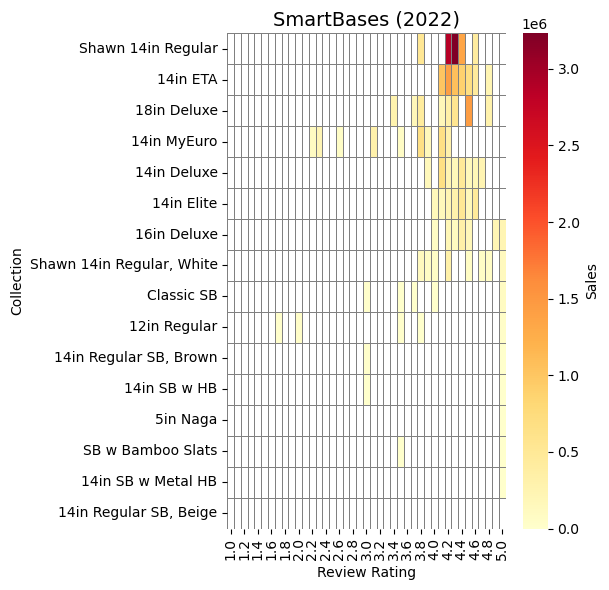

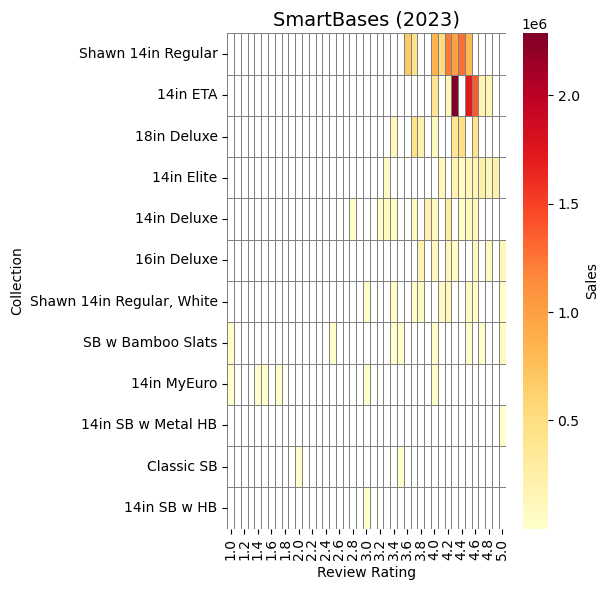

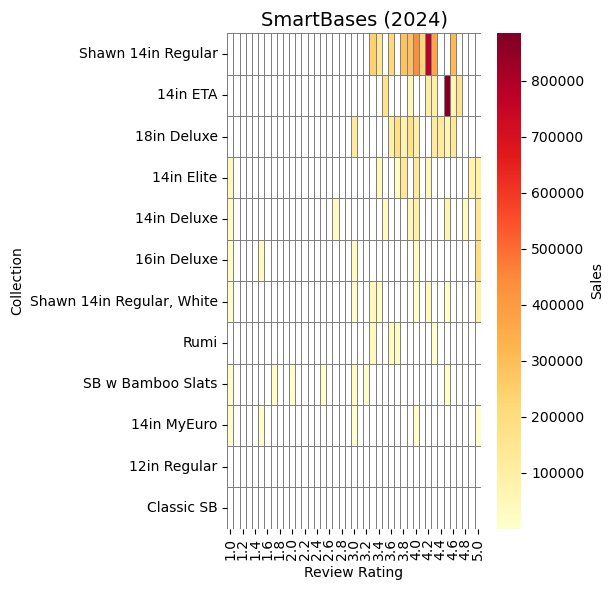

In [41]:
for year in ['2022','2023','2024']:
    pivot = (
        smartbase_cols[smartbase_cols['year']==year]
        .groupby(['collection','rating_bin'])['sales_amount']
        .sum()
        .unstack(fill_value=0)
       # .sort_index()
    )

    #누락 평점 구간을 포함시키고 정렬
    pivot = pivot.reindex(columns=rating_bins, fill_value=0)
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

    # 힌색으로 마스킹 하기
    mask = pivot == 0
    
    plt.figure(figsize=(6,6))
    sns.heatmap(pivot, cmap='YlOrRd', mask=mask, linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Sales'}, square=False)
                                                                                  
    plt.title(f'SmartBases ({year})', fontsize=14)
    plt.xlabel('Review Rating')
    plt.ylabel('Collection')
    plt.tight_layout()
    plt.show()
    